## Slip 1

In [63]:
import numpy as np

def step(x):
    return 1 if x > 0 else 0

class Perceptron:
    def __init__(self, input_size, learning_rate=0.1, epochs=10):
        self.weights = np.zeros(input_size)
        self.bias = 0
        self.lr = learning_rate
        self.epochs = epochs

    def predict(self, x):
        linear_output = np.dot(self.weights, x) + self.bias
        return step(linear_output)

    def train(self, X, y):
        for epoch in range(self.epochs):
            print(f"\nEpoch {epoch+1}")
            for xi, target in zip(X, y):
                prediction = self.predict(xi)
                error = target - prediction
                # Update rule
                self.weights += self.lr * error * xi
                self.bias += self.lr * error
                print(f"Input:{xi}, Target:{target}, Predicted:{prediction}, Weights:{self.weights}, Bias:{self.bias}")
            
            # ✅ Compute accuracy after each epoch (after going through all samples)
            predictions = np.array([self.predict(xi) for xi in X])
            correct = np.sum(predictions == y)
            accuracy = (correct / len(y)) * 100
            print(f"Epoch {epoch+1}: Accuracy = {accuracy:.2f}%")

# XOR dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 1, 1, 0])

# Create and train perceptron
perceptron = Perceptron(input_size=2, learning_rate=0.1, epochs=10)
perceptron.train(X, y)

print("\nTesting:")
for xi in X:
    print(f"Input:{xi}, Predicted:{perceptron.predict(xi)}")



Epoch 1
Input:[0 0], Target:0, Predicted:0, Weights:[0. 0.], Bias:0.0
Input:[0 1], Target:1, Predicted:0, Weights:[0.  0.1], Bias:0.1
Input:[1 0], Target:1, Predicted:1, Weights:[0.  0.1], Bias:0.1
Input:[1 1], Target:0, Predicted:1, Weights:[-0.1  0. ], Bias:0.0
Epoch 1: Accuracy = 50.00%

Epoch 2
Input:[0 0], Target:0, Predicted:0, Weights:[-0.1  0. ], Bias:0.0
Input:[0 1], Target:1, Predicted:0, Weights:[-0.1  0.1], Bias:0.1
Input:[1 0], Target:1, Predicted:0, Weights:[0.  0.1], Bias:0.2
Input:[1 1], Target:0, Predicted:1, Weights:[-0.1  0. ], Bias:0.1
Epoch 2: Accuracy = 50.00%

Epoch 3
Input:[0 0], Target:0, Predicted:1, Weights:[-0.1  0. ], Bias:0.0
Input:[0 1], Target:1, Predicted:0, Weights:[-0.1  0.1], Bias:0.1
Input:[1 0], Target:1, Predicted:0, Weights:[0.  0.1], Bias:0.2
Input:[1 1], Target:0, Predicted:1, Weights:[-0.1  0. ], Bias:0.1
Epoch 3: Accuracy = 50.00%

Epoch 4
Input:[0 0], Target:0, Predicted:1, Weights:[-0.1  0. ], Bias:0.0
Input:[0 1], Target:1, Predicted:0, W

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8764 - loss: 0.4208 - val_accuracy: 0.9753 - val_loss: 0.0874
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9815 - loss: 0.0623 - val_accuracy: 0.9855 - val_loss: 0.0519
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9873 - loss: 0.0412 - val_accuracy: 0.9878 - val_loss: 0.0401
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9917 - loss: 0.0259 - val_accuracy: 0.9898 - val_loss: 0.0379
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9938 - loss: 0.0209 - val_accuracy: 0.9898 - val_loss: 0.0379

Test Accuracy: 98.98%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


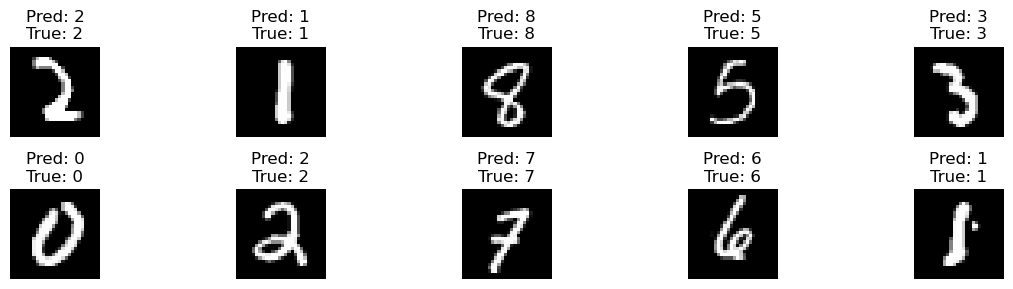

In [67]:
# Basic CNN on MNIST Dataset

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Load and preprocess MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension (since CNN expects 3D input)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

# 2️⃣ Build the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3️⃣ Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4️⃣ Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)

# 5️⃣ Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# 6️⃣ Visualize sample predictions
num_samples = 10
indices = np.random.choice(len(X_test), num_samples, replace=False)
sample_images = X_test[indices]
sample_labels = y_test[indices]

predictions = np.argmax(model.predict(sample_images), axis=1)

plt.figure(figsize=(12, 3))
for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {predictions[i]}\nTrue: {sample_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


## Slip 2

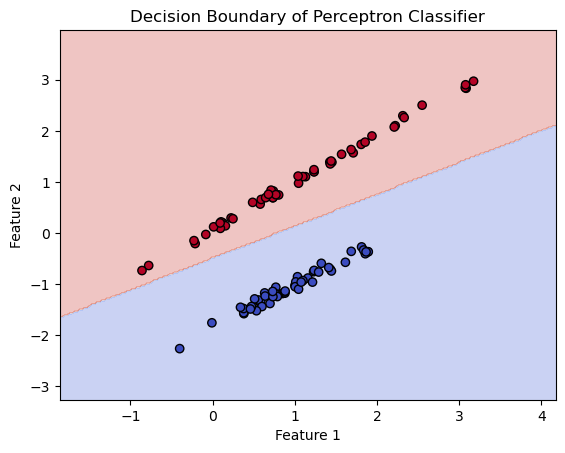

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.datasets import make_classification

# 1️⃣ Generate a simple 2D dataset
X, y = make_classification(
    n_samples=100, n_features=2, n_classes=2, 
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

# 2️⃣ Train a Perceptron model
model = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
model.fit(X, y)

# 3️⃣ Create a mesh grid for the background
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# 4️⃣ Compute predictions over the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5️⃣ Plot decision boundary and data points
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title("Decision Boundary of Perceptron Classifier")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [144]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# 1. Sample text data
text = "hello world. this is a simple rnn example."
chars = sorted(list(set(text)))  # Unique characters
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

# 2. Prepare sequences
seq_length = 10
step = 1
sequences = []
next_chars = []

for i in range(0, len(text) - seq_length, step):
    seq = text[i: i + seq_length]
    next_char = text[i + seq_length]
    sequences.append([char_to_idx[c] for c in seq])
    next_chars.append(char_to_idx[next_char])

X = np.array(sequences)
y = tf.keras.utils.to_categorical(next_chars, num_classes=len(chars))

# 3. Build the RNN model
model = Sequential([
    Embedding(input_dim=len(chars), output_dim=16, input_length=seq_length),
    SimpleRNN(128, return_sequences=False),
    Dense(len(chars), activation='softmax')
])

# 4. Compile model with accuracy metric
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# 5. Train and save history
history = model.fit(X, y, batch_size=32, epochs=30)

# 6. Print final training accuracy
final_accuracy = history.history['accuracy'][-1]
print(f"Final training accuracy: {final_accuracy:.4f}")

# 7. Text generation function
def generate_text(seed, length=100):
    generated = seed
    for _ in range(length):
        input_seq = np.array([[char_to_idx.get(c, 0) for c in generated[-seq_length:]]])
        preds = model.predict(input_seq, verbose=0)[0]
        next_char = idx_to_char[np.argmax(preds)]
        generated += next_char
    return generated

# 8. Generate text
seed = "hello worl"
print("Seed:", seed)
print("Generated:", generate_text(seed, length=50))


Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_22 (Embedding)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_15 (SimpleRNN)            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0312 - loss: 2.8374
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.1562 - loss: 2.7987
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.3438 - loss: 2.7594
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4375 - loss: 2.7167
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3438 - loss: 2.6680
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2500 - loss: 2.6107
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2188 - loss: 2.5441
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.2188 - loss: 2.4730
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2188 - loss: 2.4134
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.2188 - loss: 2.3758
Epoch 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2188 - loss: 2.3282
Epoch 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2188 - loss: 2.2555
Ep

## Slip 3

Epoch 1/5


C:\Users\SUSHANT\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.8105 - loss: 0.5832 - val_accuracy: 0.9868 - val_loss: 0.0466
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.9742 - loss: 0.0877 - val_accuracy: 0.9888 - val_loss: 0.0390
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9816 - loss: 0.0621 - val_accuracy: 0.9902 - val_loss: 0.0360
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9845 - loss: 0.0540 - val_accuracy: 0.9918 - val_loss: 0.0290
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9871 - loss: 0.0422 - val_accuracy: 0.9922 - val_loss: 0.0310
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9915 - loss: 0.0252
Test Accuracy: 0.9923


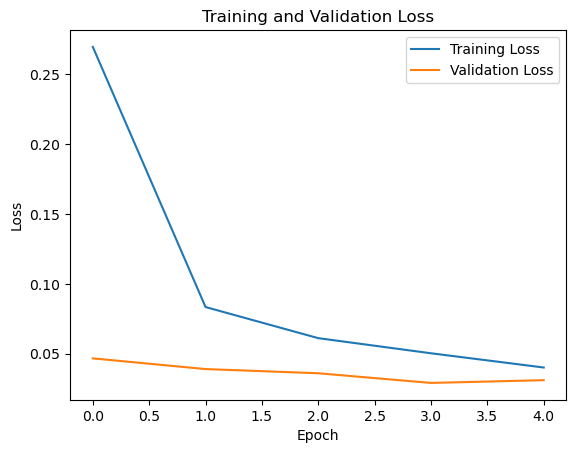

In [107]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = np.expand_dims(x_train, -1) / 255.0  # (28, 28, 1)
x_test = np.expand_dims(x_test, -1) / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Fast VGG-like CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
 
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train quickly
history=model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {acc:.4f}")

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 204s 572ms/step - accuracy: 0.2560 - loss: 1.9728 - val_accuracy: 0.4806 - val_loss: 1.4324
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 179s 510ms/step - accuracy: 0.5511 - loss: 1.2445 - val_accuracy: 0.6696 - val_loss: 0.9475
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 185s 525ms/step - accuracy: 0.6661 - loss: 0.9511 - val_accuracy: 0.7044 - val_loss: 0.8402
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 190s 541ms/step - accuracy: 0.7333 - loss: 0.7687 - val_accuracy: 0.7528 - val_loss: 0.7050
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 183s 519ms/step - accuracy: 0.7747 - loss: 0.6408 - val_accuracy: 0.7912 - val_loss: 0.6210
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.7767 - loss: 0.6452
Test Accuracy: 0.7765


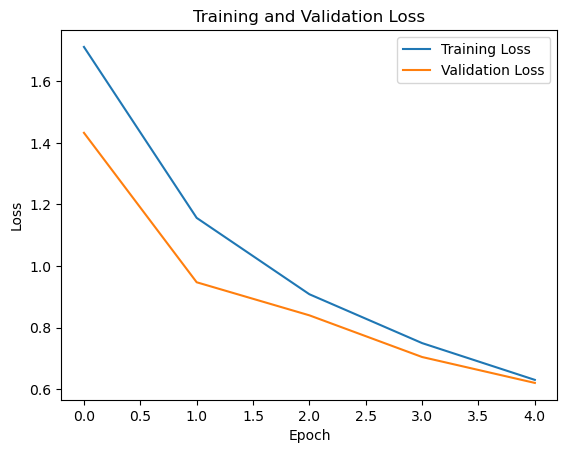

In [117]:
#2.2 VGG
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess MNIST
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = np.expand_dims(x_train, -1) / 255.0  # (28, 28, 1)
x_test = np.expand_dims(x_test, -1) / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Fast VGG-like CNN
model = models.Sequential([
    # Block 1
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Classifier
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train quickly
history=model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {acc:.4f}")

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


In [120]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

X=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([[0],[1],[1],[0]])

model=Sequential()
model.add(Dense(4,input_dim=2,activation='tanh'))
model.add(Dense(4,activation='tanh'))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate=0.01),metrics=['accuracy'])
model.fit(X,y,epochs=500,verbose=0)

print("\nPrediction on XOR inputs:")
print(model.predict(X).round())


C:\Users\SUSHANT\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Prediction on XOR inputs:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
[[0.]
 [1.]
 [1.]
 [0.]]


## Slip 4

In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

#  Resize and convert to 3 channels
X_train = tf.image.resize(tf.expand_dims(X_train, -1), [32, 32])
X_test = tf.image.resize(tf.expand_dims(X_test, -1), [32, 32])

X_train = tf.image.grayscale_to_rgb(X_train)
X_test = tf.image.grayscale_to_rgb(X_test)

#  Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

#  One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))
for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=128)

print(f"\nFinal Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Test Accuracy: {history.history['val_accuracy'][-1]:.4f}")


KeyboardInterrupt: 

In [136]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM,GRU, Dense

# 1. Sample text data
text = "hello world. this is a simple text generation example using lstm and gru models."
chars = sorted(list(set(text)))  # Unique characters
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

# 2. Prepare sequences
seq_length = 10
step = 1
sequences = []
next_chars = []

for i in range(0, len(text) - seq_length, step):
    seq = text[i: i + seq_length]
    next_char = text[i + seq_length]
    sequences.append([char_to_idx[c] for c in seq])
    next_chars.append(char_to_idx[next_char])

X = np.array(sequences)
y = tf.keras.utils.to_categorical(next_chars, num_classes=len(chars))

# 3. Build the RNN model
def build_model(cell_type='LSTM'):
    model = Sequential([
    Embedding(input_dim=len(chars), output_dim=32, input_length=seq_length),
    (LSTM(128) if cell_type == 'LSTM' else GRU(128)),
    Dense(len(chars), activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

lstm_model=build_model('LSTM')
gru_model=build_model('GRU')

history_lstm=lstm_model.fit(X, y, batch_size=32, epochs=20,verbose=0)
history_gru=gru_model.fit(X, y, batch_size=32, epochs=20,verbose=0)

# 6. Print final training accuracy
final_accuracy_lstm = history_lstm.history['accuracy'][-1]
final_accuracy_gru = history_gru.history['accuracy'][-1]
print(f"Final training accuracy_lstm: {final_accuracy_lstm:.4f}")
print(f"Final training accuracy_gru: {final_accuracy_gru:.4f}")

# 7. Text generation function
def generate_text(model, seed_text, length=100):
    generated = seed_text
    for _ in range(length):
        input_seq = np.array([[char_to_idx.get(c, 0) for c in generated[-seq_length:]]])
        preds = model.predict(input_seq, verbose=0)[0]
        next_char = idx_to_char[np.argmax(preds)]
        generated += next_char
    return generated

# 8. Generate text
seed = "hello worl"
print("Seed:", seed)
print("\nLSTM Generated Text:\n", generate_text(lstm_model, seed))
print("\nGRU Generated Text:\n", generate_text(gru_model, seed))


Final training accuracy_lstm: 0.1714
Final training accuracy_gru: 0.1714
Seed: hello worl

LSTM Generated Text:
 hello worl                                                                                                    

GRU Generated Text:
 hello worl                                                                                                    


## Slip5

In [149]:
# 1️⃣ Import required libraries
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models

# 2️⃣ Load dataset
data = load_breast_cancer()
X, y = data.data, data.target
print("Feature shape:", X.shape)
print("Classes:", data.target_names)

# 3️⃣ Preprocess and reshape for CNN
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape into 2D (CNN expects image-like input)
# 30 features → reshape into 6x5 "image" with 1 channel
X = X.reshape(X.shape[0], 6, 5, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4️⃣ Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (2, 2), activation='relu', input_shape=(6, 5, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (2, 2), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# 5️⃣ Train model
history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test), verbose=1)

# 6️⃣ Evaluate on test data
y_pred = (model.predict(X_test) > 0.5).astype("int32").flatten()

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# 7️⃣ Print evaluation metrics
print("\n✅ CNN Model Evaluation Results:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Feature shape: (569, 30)
Classes: ['malignant' 'benign']


C:\Users\SUSHANT\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)                   │ (None, 5, 4, 32)            │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 2, 2, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_28 (Conv2D)                   │ (None, 1, 1, 64)            │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_10 (Flatten)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,641 (49.38 KB)

 Trainable params: 12,641 (49.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6813 - loss: 0.6068 - val_accuracy: 0.8860 - val_loss: 0.3361
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8380 - loss: 0.3741 - val_accuracy: 0.9386 - val_loss: 0.1940
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9228 - loss: 0.2424 - val_accuracy: 0.9649 - val_loss: 0.1357
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9370 - loss: 0.1614 - val_accuracy: 0.9649 - val_loss: 0.1111
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9512 - loss: 0.1446 - val_accuracy: 0.9649 - val_loss: 0.0881
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9542 - loss: 0.1217 - val_accuracy: 0.9737 - val_loss: 0.0834
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9731 - loss: 0.0887 - val_accuracy: 0.9737 - val_loss: 0.0839
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9524 - loss: 0.1244 - val_accuracy: 0.9561 - val_los

In [160]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Load MNIST Dataset (handwritten digits)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to [0,1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# Flatten 28x28 images into 784-dim vectors
X_train = X_train.reshape((X_train.shape[0], 28*28))
X_test  = X_test.reshape((X_test.shape[0], 28*28))

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

#  Build a simple Neural Network
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

#  Compile using SGD optimizer
sgd_optimizer = optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(optimizer=sgd_optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

#  Train model
history = model.fit(X_train, y_train_cat, 
                    epochs=10, 
                    batch_size=32, 
                    validation_split=0.1,
                    verbose=1)

# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

#  Predictions and classification report
y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


C:\Users\SUSHANT\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_52 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_53 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8421 - loss: 0.5255 - val_accuracy: 0.9678 - val_loss: 0.1150
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9604 - loss: 0.1296 - val_accuracy: 0.9727 - val_loss: 0.0936
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9723 - loss: 0.0889 - val_accuracy: 0.9757 - val_loss: 0.0828
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9791 - loss: 0.0664 - val_accuracy: 0.9747 - val_loss: 0.0917
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9834 - loss: 0.0539 - val_accuracy: 0.9820 - val_loss: 0.0719
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9879 - loss: 0.0388 - val_accuracy: 0.9780 - val_loss: 0.0796
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9892 - loss: 0.0341 - val_accuracy: 0.9790 - val_loss: 0.0773
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9918 - loss: 0.0261 - 

## Slip 6

In [168]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Load MNIST Dataset (handwritten digits)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to [0,1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# Flatten 28x28 images into 784-dim vectors
X_train = X_train.reshape((X_train.shape[0], 28*28))
X_test  = X_test.reshape((X_test.shape[0], 28*28))

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

#  Build a simple Neural Network
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

#  Train model
history = model.fit(X_train, y_train_cat, 
                    epochs=5, 
                    batch_size=32, 
                    validation_split=0.1,
                    verbose=1)

# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

#  Predictions and classification report
y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

C:\Users\SUSHANT\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_64 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_65 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,154 (430.29 KB)

 Trainable params: 109,770 (428.79 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8322 - loss: 0.5397 - val_accuracy: 0.9635 - val_loss: 0.1196
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9387 - loss: 0.2039 - val_accuracy: 0.9735 - val_loss: 0.0954
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9462 - loss: 0.1712 - val_accuracy: 0.9717 - val_loss: 0.0851
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9549 - loss: 0.1430 - val_accuracy: 0.9765 - val_loss: 0.0770
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9576 - loss: 0.1347 - val_accuracy: 0.9805 - val_loss: 0.0675

✅ Test Accuracy: 0.9755
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.97      0.97      0.97 

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0737
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0696 
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0699 
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0701 
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0653 
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0686 
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0612 
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0638 
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0670 
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0633 
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0610 
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0644 
Epoch 13/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0589 
Epoch 14/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0586 
Epoch 15/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss

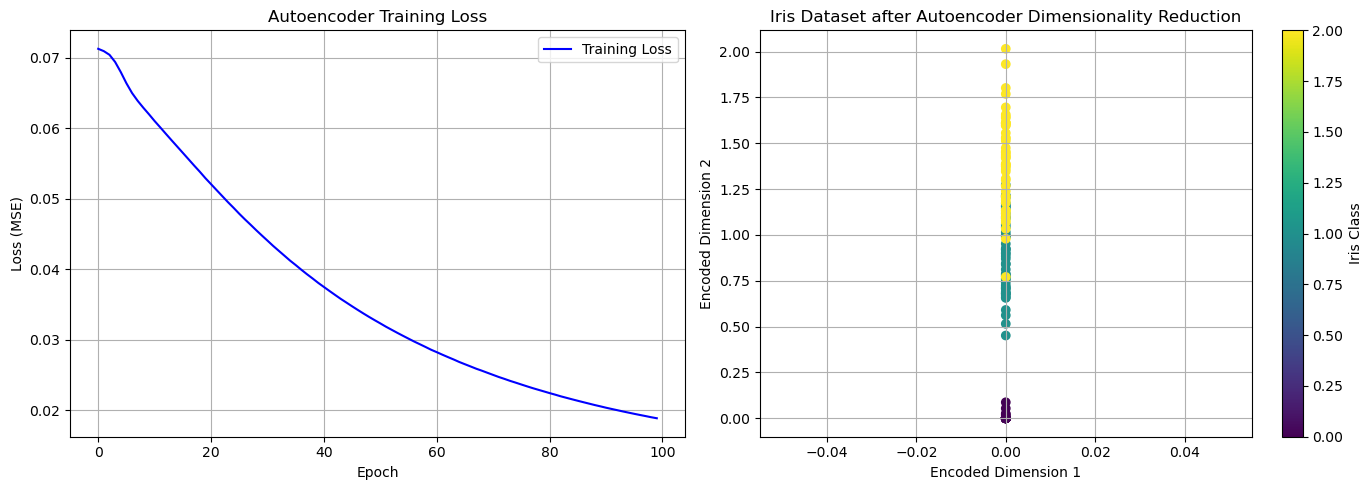


Original data shape: (150, 4)
Reduced data shape: (150, 2)


In [170]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Load the iris dataset
iris = load_iris()
X = iris.data

# Scale the data between 0 and 1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Encoder
input_layer = Input(shape=(4,))
encoder = Dense(2, activation='relu')(input_layer)

# Decoder
decoder = Dense(4, activation='sigmoid')(encoder)

# Autoencoder model
autoencoder = Model(inputs=input_layer, outputs=decoder)

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

# Train the autoencoder
epochs = 100
batch_size = 10
history=autoencoder.fit(X_scaled, X_scaled,
                epochs=epochs,
                batch_size=batch_size,
                verbose=1,
                )

# Create an encoder model to get the reduced dimensions
encoder_model = Model(inputs=input_layer, outputs=encoder)

# Get the reduced dimensions for the original data
X_encoded = encoder_model.predict(X_scaled)

# Visualize the reduced data (2D)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.legend()

# Plot 2: Encoded data
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_encoded[:, 0], X_encoded[:, 1], c=iris.target, cmap='viridis')
plt.title('Iris Dataset after Autoencoder Dimensionality Reduction')
plt.xlabel('Encoded Dimension 1')
plt.ylabel('Encoded Dimension 2')
plt.colorbar(scatter, label='Iris Class')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nOriginal data shape:", X_scaled.shape)
print("Reduced data shape:", X_encoded.shape)

## slip 7

In [172]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# 1. Sample text data
text = "deep learning allows computer to learn for data and make predictions"
chars = sorted(list(set(text)))  # Unique characters
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

# 2. Prepare sequences
seq_length = 10
step = 1
sequences = []
next_chars = []

for i in range(0, len(text) - seq_length, step):
    seq = text[i: i + seq_length]
    next_char = text[i + seq_length]
    sequences.append([char_to_idx[c] for c in seq])
    next_chars.append(char_to_idx[next_char])

X = np.array(sequences)
y = tf.keras.utils.to_categorical(next_chars, num_classes=len(chars))

# 3. Build the RNN model
model = Sequential([
    Embedding(input_dim=len(chars), output_dim=16, input_length=seq_length),
    SimpleRNN(128, return_sequences=False),
    Dense(len(chars), activation='softmax')
])

# 4. Compile model with accuracy metric
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# 5. Train and save history
history = model.fit(X, y, batch_size=32, epochs=30)

# 6. Print final training accuracy
final_accuracy = history.history['accuracy'][-1]
print(f"Final training accuracy: {final_accuracy:.4f}")

# 7. Text generation function
def generate_text(seed, length=100):
    generated = seed
    for _ in range(length):
        input_seq = np.array([[char_to_idx.get(c, 0) for c in generated[-seq_length:]]])
        preds = model.predict(input_seq, verbose=0)[0]
        next_char = idx_to_char[np.argmax(preds)]
        generated += next_char
    return generated

# 8. Generate text
seed = "deep learning"
print("Seed:", seed)
print("Generated:", generate_text(seed, length=50))


C:\Users\SUSHANT\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_25 (Embedding)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_16 (SimpleRNN)            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_68 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.0991 - loss: 2.9240
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2662 - loss: 2.8703 
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2777 - loss: 2.8047
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1994 - loss: 2.7230
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2098 - loss: 2.6105
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1889 - loss: 2.5374
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1796 - loss: 2.5306
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2892 - loss: 2.4004
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2996 - loss: 2.3018
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3549 - loss: 2.1616
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2902 - loss: 2.0794
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4102 - loss: 1.9579


In [191]:
# 1️⃣ Import libraries
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# 2️⃣ Load and preprocess data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], -1).astype("float32") / 255.0  # Flatten 28x28 → 784
X_test  = X_test.reshape(X_test.shape[0], -1).astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

# 3️⃣ Function to build a DNN with variable depth
def build_dnn(num_hidden_layers=1, units_per_layer=128):
    model = models.Sequential()
    model.add(layers.Input(shape=(784,)))
    for _ in range(num_hidden_layers):
        model.add(layers.Dense(units_per_layer, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 4️⃣ Train and evaluate models of increasing depth
depths = [1, 2, 3, 5]
results = {}

for d in depths:
    print(f"\n🔹 Training DNN with {d} hidden layer(s)...")
    model = build_dnn(num_hidden_layers=d)
    history = model.fit(X_train, y_train, epochs=10, batch_size=128, verbose=0, validation_data=(X_test, y_test))
    test_acc = history.history['val_accuracy'][-1]
    results[d] = test_acc
    print(f"✅ Depth {d}: Test Accuracy = {test_acc:.4f}")

# 5️⃣ Display results
print("\n📊 Accuracy vs Depth")
for depth, acc in results.items():
    print(f"Layers: {depth:>2} → Accuracy: {acc:.4f}")



🔹 Training DNN with 1 hidden layer(s)...
✅ Depth 1: Test Accuracy = 0.9785

🔹 Training DNN with 2 hidden layer(s)...
✅ Depth 2: Test Accuracy = 0.9783

🔹 Training DNN with 3 hidden layer(s)...
✅ Depth 3: Test Accuracy = 0.9757

🔹 Training DNN with 5 hidden layer(s)...
✅ Depth 5: Test Accuracy = 0.9792

📊 Accuracy vs Depth
Layers:  1 → Accuracy: 0.9785
Layers:  2 → Accuracy: 0.9783
Layers:  3 → Accuracy: 0.9757
Layers:  5 → Accuracy: 0.9792


## Slip 8

In [187]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Load MNIST Dataset (handwritten digits)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to [0,1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# Flatten 28x28 images into 784-dim vectors
X_train = X_train.reshape((X_train.shape[0], 28*28))
X_test  = X_test.reshape((X_test.shape[0], 28*28))

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

#  Build a simple Neural Network
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

#  Compile using SGD optimizer
adam_optimizer = optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=adam_optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

#  Train model
history = model.fit(X_train, y_train_cat, 
                    epochs=10, 
                    batch_size=32, 
                    validation_split=0.1,
                    verbose=1)

# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

#  Predictions and classification report
y_pred = np.argmax(model.predict(X_test), axis=1)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


C:\Users\SUSHANT\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_96 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_97 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_98 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8659 - loss: 0.4550 - val_accuracy: 0.9662 - val_loss: 0.1238
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9648 - loss: 0.1180 - val_accuracy: 0.9745 - val_loss: 0.0889
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9758 - loss: 0.0762 - val_accuracy: 0.9733 - val_loss: 0.0914
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9826 - loss: 0.0558 - val_accuracy: 0.9780 - val_loss: 0.0792
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9875 - loss: 0.0396 - val_accuracy: 0.9783 - val_loss: 0.0774
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9900 - loss: 0.0324 - val_accuracy: 0.9753 - val_loss: 0.0968
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9901 - loss: 0.0296 - val_accuracy: 0.9790 - val_loss: 0.0888
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9932 - loss: 0.0206 - 

## Slice 9

In [185]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Load and preprocess dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

X_train, X_test = X_train / 255.0, X_test / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()

# 2️⃣ Build AlexNet model
model = models.Sequential([
    layers.Conv2D(96, (3, 3), strides=1, activation='relu', input_shape=(32, 32, 3), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(384, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(384, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# 3️⃣ Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# 4️⃣ Train model
history = model.fit(X_train, y_train, epochs=5, batch_size=128,
                    validation_data=(X_test, y_test), verbose=1)

# 5️⃣ Evaluate performance
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)                   │ (None, 32, 32, 96)          │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 32, 32, 96)          │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 16, 16, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_40 (Conv2D)                   │ (None, 16, 16, 256)         │         221,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_41 (Conv2D)                   │ (None, 8, 8, 384)           │         885,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_42 (Conv2D)                   │ (None, 8, 8, 384)           │       1,327,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_43 (Conv2D)                   │ (None, 8, 8, 256)           │         884,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_13 (Flatten)                 │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_93 (Dense)                     │ (None, 1024)                │       4,195,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_94 (Dense)                     │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_95 (Dense)                     │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,048,394 (30.70 MB)

 Trainable params: 8,047,690 (30.70 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 372s 944ms/step - accuracy: 0.3356 - loss: 1.8427 - val_accuracy: 0.1433 - val_loss: 3.7758
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 355s 907ms/step - accuracy: 0.6265 - loss: 1.0636 - val_accuracy: 0.6347 - val_loss: 1.0497
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 327s 838ms/step - accuracy: 0.7114 - loss: 0.8427 - val_accuracy: 0.6032 - val_loss: 1.1889
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 348s 891ms/step - accuracy: 0.7574 - loss: 0.7053 - val_accuracy: 0.6421 - val_loss: 1.0904
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 369s 944ms/step - accuracy: 0.7955 - loss: 0.5992 - val_accuracy: 0.7171 - val_loss: 0.8272

✅ Test Accuracy: 71.71%


In [197]:
!pip install scikeras

In [205]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.datasets import mnist

# 1️⃣ Load and preprocess data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 784).astype("float32") / 255.0
X_test = X_test.reshape(-1, 784).astype("float32") / 255.0

# 2️⃣ Define simple DNN builder
def create_model(optimizer='adam'):
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# 3️⃣ Wrap model for GridSearch
model = KerasClassifier(model=create_model, verbose=0)

# 4️⃣ Define hyperparameter grid
param_grid = {
    'batch_size': [64, 128],
    'epochs': [5, 10]
}

# 5️⃣ Perform Grid Search
grid = GridSearchCV(estimator=model,
                    param_grid=param_grid,
                    cv=3,
                    verbose=2)

grid_result = grid.fit(X_train, y_train)

# 6️⃣ Show results
print("\n✅ Best Parameters Found:")
print(grid_result.best_params_)
print(f"🏆 Best Accuracy: {grid_result.best_score_:.4f}")

# 7️⃣ Evaluate on test data
best_model = grid_result.best_estimator_.model_
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\n🧠 Test Accuracy: {test_acc:.4f}")


Fitting 3 folds for each of 4 candidates, totalling 12 fits


C:\Users\SUSHANT\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END ............................batch_size=64, epochs=5; total time=  11.4s


C:\Users\SUSHANT\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END ............................batch_size=64, epochs=5; total time=  12.3s


...

[CV] END ..........................batch_size=128, epochs=10; total time=  14.0s


C:\Users\SUSHANT\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END ..........................batch_size=128, epochs=10; total time=  13.5s


C:\Users\SUSHANT\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



✅ Best Parameters Found:
{'batch_size': 128, 'epochs': 10}
🏆 Best Accuracy: 0.9729

🧠 Test Accuracy: 0.9780


## Slip 14

In [207]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Load and preprocess MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension (since CNN expects 3D input)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

# 2️⃣ Build the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3️⃣ Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4️⃣ Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)

# 5️⃣ Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
print(cm)

# 9️⃣ Classification report (optional)
print("\nClassification Report:\n", classification_report(y_test, y_pred_classes))

Epoch 1/5


C:\Users\SUSHANT\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8565 - loss: 0.4655 - val_accuracy: 0.9837 - val_loss: 0.0593
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9821 - loss: 0.0586 - val_accuracy: 0.9855 - val_loss: 0.0476
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9880 - loss: 0.0381 - val_accuracy: 0.9882 - val_loss: 0.0402
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9912 - loss: 0.0271 - val_accuracy: 0.9870 - val_loss: 0.0427
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9928 - loss: 0.0220 - val_accuracy: 0.9893 - val_loss: 0.0442

Test Accuracy: 98.79%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.98      0.99      1032
           3       0.97      1.00      0.98      1010
           4

## Slip 11

In [ ]:
# tranfer learning using mobile net

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import cv2

# Load and preprocess MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

def preprocess_mnist(images):
    # Only process a small subset to prevent crash (e.g., first 10,000)
    processed = []
    for img in images:
        img_resized = cv2.resize(img, (96, 96))  # Use smaller input size
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_GRAY2RGB)
        processed.append(img_rgb)
    return np.array(processed, dtype='float32') / 255.0

x_train = preprocess_mnist(x_train[:10000])
y_train = to_categorical(y_train[:10000], 10)

x_test = preprocess_mnist(x_test[:2000])
y_test = to_categorical(y_test[:2000], 10)

# Load lightweight model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3))

# Freeze base layers
base_model.trainable = False

# Add custom layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(64, activation='relu')(x)
x = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
model.fit(x_train, y_train, epochs=3, batch_size=32, validation_split=0.1)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print(f"Accuracy: {acc:.4f}")


Future Trends in Deep Learning: Quantum AI and Explainable AI (XAI)

Deep Learning (DL) has demonstrated remarkable progress across domains such as computer vision, natural language processing, and autonomous systems. As computational demands and data complexity continue to increase, new directions are emerging to push the boundaries of DL. Among the most prominent trends shaping the future of Deep Learning are Quantum AI and Explainable AI (XAI).

1. Quantum AI

Quantum AI represents the intersection of quantum computing and artificial intelligence. Quantum computing leverages quantum bits (qubits) that can exist in multiple states simultaneously due to the principles of superposition and entanglement. These quantum properties allow quantum computers to perform computations at speeds that are theoretically impossible for classical systems.

Key Features and Potential Benefits:

Exponential Speedup: Quantum algorithms can solve certain types of problems, such as optimization and high-dimensional vector computation, exponentially faster than classical algorithms.

Enhanced Machine Learning Models: Quantum Machine Learning (QML) algorithms enable faster training and inference, particularly in domains like cryptography, drug design, and finance.

Capacity to Work with Complex Data: Due to its ability to handle high-dimensional and entangled data, quantum systems may improve the performance of deep neural networks, especially in reinforcement learning and generative modeling.

Challenges:

Current quantum hardware is noisy and has limited qubits.

Quantum AI models are still in the experimental phase.

Future Scope:

As quantum hardware evolves and error correction improves, hybrid architectures (quantum-classical models) are expected to emerge, enabling scalable and highly efficient deep learning systems.

2. Explainable AI (XAI)

Explainable AI (XAI) addresses a critical challenge in contemporary deep learning: its black-box nature. While DL models achieve high accuracy, they often lack interpretability, making it difficult to understand how decisions are made. This poses a risk in high-stakes applications like healthcare, finance, and autonomous driving.

Key Features and Importance:

Transparency: XAI seeks to make AI decisions understandable to human users, ensuring that the reasoning process is visible.

Trust and Accountability: By revealing how models derive outputs, XAI builds trust among stakeholders and allows for better governance.

Regulation Compliance: Regulatory frameworks such as the EU’s GDPR mandate the "right to explanation" for automated systems, making XAI necessary for legal compliance.

Approaches in XAI:

Model-Agnostic Techniques: Methods like LIME (Local Interpretable Model-Agnostic Explanations) and SHAP (SHapley Additive exPlanations) explain predictions regardless of model architecture.

Interpretable Model Design: Techniques such as attention visualization in Transformer models help users understand which parts of the input influence model decisions.

Counterfactual Explanations: By showing alternative inputs that would change the output, these explanations demonstrate decision boundaries.

Future Scope:

As deep learning systems are deployed in sensitive sectors, XAI will become integral to the development pipeline. Hybrid models combining accuracy and interpretability will likely dominate future AI applications

. Model-Agnostic Techniques

These methods can be applied to any machine learning model, including deep learning architectures.

a. LIME (Local Interpretable Model-Agnostic Explanations)

Provides local explanations around individual predictions.

Creates a simpler surrogate model (e.g., linear regression) to approximate model behavior around a specific input.

Useful for text, image, and tabular data.

b. SHAP (SHapley Additive exPlanations)

Based on Shapley values from cooperative game theory.

Measures the contribution of each feature to a model’s prediction.

Works well for both global and local interpretability.

Framework supports deep learning models via Deep SHAP.

c. Permutation Feature Importance

Measures how the accuracy of a model changes when the values of a single feature are randomly shuffled.

Indicates how important a feature is to the model’s predictions.

2. Model-Specific Techniques

These techniques are designed to interpret specific types of deep learning architectures like Convolutional Neural Networks (CNNs) or Transformers.

a. Saliency Maps

Computes gradients of the output with respect to input pixels (or features).

Highlights areas of input that most influence the prediction.

Commonly used for CNNs in computer vision tasks.

b. Grad-CAM (Gradient-weighted Class Activation Mapping)

Produces heatmaps that show which parts of an image are most important for a specific class prediction.

Useful for convolutional architecture visualizations.

c. Integrated Gradients

Measures feature importance by integrating gradients along the path from a baseline input to the actual input.

Solves the “gradient saturation” problem found in simple saliency maps.

d. Attention Visualization

Used in Transformer models or attention-based networks such as BERT or Vision Transformers (ViTs).

Visualizes how attention weights are distributed, showing which inputs are being emphasized during prediction.

3. Surrogate Models

These involve using simpler models to mimic and understand the behavior of deep networks.

a. Decision Trees as Surrogates

Train a decision tree to approximate the deep model's decision-making process.

Enables rule extraction for interpretability.

b. Rule Extraction Techniques

Generate human-readable rules based on model predictions.

Useful for understanding decision boundaries.

4. Counterfactual Explanations

Answer the question: "What minimal change would alter the model's prediction?"

Helps understand model behavior by showing how inputs can be tweaked to change the output.

Used in areas like finance (loan approvals) and healthcare (diagnosis models).

5. Partial Dependence Plots (PDPs) and Individual Conditional Expectation (ICE)

PDPs show how the model output changes with respect to a single feature, keeping all others constant.

ICE plots visualize how each individual prediction is affected by a feature.

6. Feature Visualization (for CNNs)

Visualizes what deep neural networks learn at different layers.

Helps understand what kind of patterns (e.g., edges, textures) are being captured.

Tools like DeepDream, Activation Maximization are used.